# Jev-Mem 走读与实验：给 Agent 装一个"会自己整理的记忆"

**TL;DR**：Jev-Mem 是 UT Dallas 2026 年 9 月 21 日开源的 Agent 记忆架构（[arXiv 2609.23986](https://arxiv.org/abs/2609.23986)，第二天登上 [Hugging Face 趋势榜](https://huggingface.co/papers/2609.23986)）。它的核心主张只有一句话：**记忆管理里那些高频小决策（该不该存、和谁有关、去哪找、找到没够），不值得动用大模型——交给 Jev 这样的轻量 System-One 决策模型；大模型只在最后组织答案时出场（System-Two）**。论文在 LoCoMo 基准上报告：答案质量比最强基线高 11%，建记忆快 6.6 倍，查询延迟低 36.7%。

这个 notebook 做三件事：

1. **讲明白**：Jev-Mem 的三个平面架构，以及"写入"和"读取"两条管线里 Jev 到底在做什么决策（对着真实代码走）；
2. **跑起来**：用一段中文多轮对话建记忆、做检索，System-Two 用 **DeepSeek**（`deepseek-chat`），Jev 决策有 `TYPESAFE_API_KEY` 就用真模型，没有就走代码兜底（每一步都会如实标注）；
3. **比一比**：同一组记忆问答，对比 4 种做法——滑动窗口、全上下文、朴素向量 RAG（= 卸掉 Jev 决策面）、Jev-Mem 完整管线，看质量、延迟、token 花销。

> 本地文件：代码仓库 `../Jev-Mem/`，论文 PDF `../Jev-Mem/docs/jev_mem_paper_2609.23986.pdf`。
> 运行前把 key 写进 `../Jev-Mem/.env`（格式见下面第 1 节）。没有 key 也能跑通大部分内容。

> **续篇**：[jev_mem_scaling.ipynb](jev_mem_scaling.ipynb) 把同一组四臂实验拉到 48~384 轮的长程场景，并附真 LoCoMo（419 轮）对照——长对话下质量反转与 token 剪刀差都在那一篇。末节有三组实验的结论总览与选型判据。

## 1. 背景：Jev 一個模型不够吗？

在前面的 cookbook 章节里，Jev 的标准用法是"一次决策调用"：发一段状态 + 一组类型化问题（Noul 命题概率 / Choice 选项分布），拿回结构化答案。这在单点任务上很好用，但**长期运行的 Agent 记忆**是一整条流水线，每一步都塞着小决策：

| 记忆环节 | 里面藏着的决策 | 用大模型做的问题 |
|---|---|---|
| 写入 | 这句话值得存吗？是情节、语义、程序还是偏好？ | 每条记忆一次生成调用，慢且贵 |
| 建联 | 新记忆和哪条旧记忆有语义/因果/实体关系？ | 候选两两比较，调用量随记忆数增长 |
| 检索 | 该查哪几张关系图？走多深？这条候选有用吗？ | 检索路径上反复生成，延迟被放大 |
| 停止 | 证据够了吗？再找一轮值不值？ | 不停就超时，停早了漏证据 |

A-MEM、MemoryOS 这类系统把上述决策全交给大模型自由生成，论文实测它们建一次记忆要 3000 秒以上。Jev-Mem 的做法是把这条决策链**整体搬到一个专门的 System-One 控制面**上，用类型化、带概率、可批量的小决策替代自由生成。

**论文信息**

| 项目 | 内容 |
|---|---|
| 标题 | Jev-Mem: System-One-Controlled Agentic Memory for Efficient AI Agents |
| 作者 | Dongming Jiang, Yi Li, Bingzhe Li（UT Dallas） |
| 时间 | 2026-09-21 开源，09-22 登上 HF Papers 趋势榜 |
| 代码 | https://github.com/libingzheren/Jev-Mem |
| 论文 | https://arxiv.org/abs/2609.23986 |

## 2. 架构：三个平面，两条管线

![Jev-Mem 架构](overall_structure.png)

三个平面各管一件事：

| 平面 | 谁来做 | 职责 |
|---|---|---|
| **System-One 控制面** | Jev（`jev-latest`，走 TypeSafe API） | 高频、结构化的小决策：打类型分、判关系、选路由、给预算、评候选、判停止 |
| **记忆面** | 普通代码（networkx + 向量库 + BM25） | 保存原始观察（带时间戳和出处），维护 semantic / temporal / causal / entity 四张关系图视图，向量+关键词双索引 |
| **System-Two 推理面** | 任意 OpenAI 兼容大模型（**本 notebook 用 DeepSeek**） | 只做两件事：答复杂问题、组织最终答案 |

两条管线的决策点（对着代码）：

**写入**（`memory/memory_builder.py: build()`）：
观察进来 → ① Jev 判类型（episodic/semantic/procedural/preference 四个独立概率）→ ② 代码用向量+关键词+实体+时间找出有界候选集（默认 top-10）→ ③ Jev 逐对判关系（语义相关？谁导致谁？同一实体？），时间先后这类确定性关系由代码直接建 → ④ 入图，四张视图同步更新。默认档案**不删任何原始观察**——现在没用的细节以后可能有用。

**读取**（`memory/jev_mem_retrieval.py: RetrievalController.query()`）：
问题进来 → ① Jev 路由：四张关系图各需要多少（Noul 概率），要不要多跳，要不要最新事实 → ② 向量+关键词锚点起步 → ③ 代码按路由概率分配**整数遍历预算**（最大余数法，总数不超上限）→ ④ 沿图扩展，Jev 给每个新候选打分（有用/新信息/佐证）→ ⑤ 每轮结束 Jev 判停止：证据够了吗？再找还有用吗？→ ⑥ 选出的证据交给 System-Two 组织答案。

**Jev 一共被问了 7 组问题**（定义在 `memory/jev_questions.py`，全部是 Noul 概率，只有整理决策用一个 Choice）：

| 问题组 | 时机 | 内容 |
|---|---|---|
| admission | 写入 | 值得存吗 / 未来有用吗 / 重要吗 / 新颖吗 / 冗余吗 |
| memory_type | 写入 | episodic / semantic / procedural / preference 四个独立类型分 |
| relation | 写入 | 和每条候选：语义相关？谁导致谁？同一实体？ |
| consolidation | 写入（周期） | 重复/矛盾/过时/该合并还是该抽象（唯一 Choice） |
| routing | 读取 | 四张图各需要吗、要多跳吗、要最新吗 |
| traversal | 读取 | 这条候选相关吗 / 关系有用吗 / 有新信息吗 / 佐证吗 |
| stopping | 读取 | 证据够吗 / 再找有用吗 / 缺什么 / 有矛盾吗 |

## 3. 环境准备

**一次性准备**（本机已做好）：

```bash
cd ../Jev-Mem
python3.11 -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
```

**配置 key**：编辑 `../Jev-Mem/.env`（没有就新建）：

```dotenv
# System-Two：DeepSeek（OpenAI 兼容接口，代码零改动）
DEEPSEEK_API_KEY=sk-你的deepseek-key
# System-One：真 Jev 决策（可选，没有则走代码兜底并在输出中标注）
TYPESAFE_API_KEY=你的typesafe-key
```

- 有 DeepSeek key：第 5、6 节实验可跑。
- 有 Typesafe key：Jev-Mem 臂用真 Jev 决策；没有时用确定性兜底逻辑，**结果会打折，但管线完整**，输出里会明确标注决策来源（jev / fallback）。
- embedding 走硅基流动的 `Qwen/Qwen3-Embedding-0.6B`（OpenAI 兼容 `/embeddings`，1024 维，中文强）：在 `.env` 加 `SILICONFLOW_API_KEY=sk-...`。没有该 key 时自动回落本地 `paraphrase-multilingual-MiniLM-L12-v2`（首次从 HuggingFace 下载），管线其余部分不变。

In [1]:
import os, sys, json, time, re
from pathlib import Path

REPO = Path("../Jev-Mem").resolve()
sys.path.insert(0, str(REPO))
os.chdir(REPO)

from dotenv import load_dotenv
load_dotenv(REPO / ".env")

# DeepSeek 接入：项目代码只认 OPENAI_API_KEY / OPENAI_BASE_URL，
# 而 openai SDK 会自动读这两个环境变量，所以做个映射即可，代码零改动。
if os.getenv("DEEPSEEK_API_KEY") and not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = os.environ["DEEPSEEK_API_KEY"]
os.environ.setdefault("OPENAI_BASE_URL", "https://api.deepseek.com")

ANSWER_MODEL = os.getenv("ANSWER_MODEL", "deepseek-chat")   # System-Two 模型
HAS_DEEPSEEK = bool(os.getenv("OPENAI_API_KEY"))
HAS_TYPESAFE = bool(os.getenv("TYPESAFE_API_KEY"))

print(f"System-Two (答案+评审): {ANSWER_MODEL} @ {os.environ.get('OPENAI_BASE_URL')}  -> {'可用' if HAS_DEEPSEEK else '未配置 key'}")
print(f"System-One (Jev 决策) : jev-latest @ https://api.typesafe.ai  -> {'真 Jev' if HAS_TYPESAFE else '无 key，走代码兜底'}")

System-Two (答案+评审): deepseek-chat @ https://api.deepseek.com  -> 可用
System-One (Jev 决策) : jev-latest @ https://api.typesafe.ai  -> 真 Jev


## 4. 离线走读 · 写入管线：一条观察是怎么变成"记忆"的

检测到 `TYPESAFE_API_KEY` 时，这段走读直接用**真 Jev**（审计日志里 `source=jev`）；没有 key 时自动挂上**教学 mock 决策器**——它模拟 Jev 的调用契约（同样的 state + questions → 概率），用中文关键词启发式给分（审计里 `source=mock`）。两种模式的管线一行不改：这正是 Jev-Mem 的可编程性，**决策面是可插拔的**。

In [2]:
from typesafe_sdk import Noul, Choice

def teaching_mock_jev(operation, state, questions):
    """教学 mock：与 Jev 同款调用契约（state + questions -> 概率），中文启发式给分。
    返回扁平的 {问题名: 概率}，JevClient 会包成类型化响应并走同一条校验/审计路径。"""
    obs = state.get("observation") or (state.get("new_memory") or {}).get("content", "")

    def heuristics():
        if operation in ("observation", "memory_type"):
            has_pref = any(w in obs for w in ("喜欢", "倾向", "偏好", "决定"))
            has_event = any(w in obs for w in ("去", "定", "改", "结婚", "体检", "爬山", "学"))
            has_howto = any(w in obs for w in ("步骤", "先", "再", "然后"))
            return dict(should_store=0.95 if len(obs) > 8 else 0.1,
                        future_utility=0.9, importance=0.8, novelty=0.9, redundancy=0.05,
                        episodic=0.9 if has_event else 0.2,
                        semantic=0.8 if len(obs) > 8 else 0.2,
                        procedural=0.9 if has_howto else 0.05,
                        preference=0.9 if has_pref else 0.1)
        if operation == "relations":
            out = {}
            for i in range(len(state.get("candidates", []))):
                other = state["candidates"][i]["content"]
                shared = len(set(obs) & set(other)) / max(1, len(set(obs) | set(other)))
                out[f"pair_{i}_semantic"] = min(0.95, shared * 3)
                out[f"pair_{i}_causes"] = 0.9 if ("改到" in obs or "推迟" in obs) and "出差" in other else 0.05
                out[f"pair_{i}_caused_by"] = 0.05
                out[f"pair_{i}_entity"] = 0.8 if any(e in other for e in state["new_memory"].get("entities", [])) else 0.05
            return out
        if operation == "routing":
            return dict(semantic=0.9,
                        temporal=0.9 if any(w in state["query"] for w in ("什么时候", "哪天", "时间", "多长")) else 0.2,
                        causal=0.9 if any(w in state["query"] for w in ("为什么", "原因", "变化")) else 0.2,
                        entity=0.8, multi_hop_need=0.8, recency_importance=0.2)
        if operation == "stopping":
            deep = state.get("depth", 0) >= 1
            return dict(evidence_sufficient=0.9 if deep else 0.3,
                        continue_useful=0.2 if deep else 0.8,
                        missing_evidence=0.1 if deep else 0.7, contradiction=0.05)
        if operation == "traversal":
            return dict.fromkeys(questions, 0.8)
        return {}

    base = heuristics()
    out = {}
    for name, q in questions.items():
        if isinstance(q, Noul):
            out[name] = float(base.get(name, 0.5))
        else:  # Choice：教学 mock 里不会触发，兜一个单选分布
            opt = list(q.criteria)[0]
            out[name] = {"type": "choice", "choice": opt,
                         "probabilities": {k: float(k == opt) for k in q.criteria},
                         "confidence": 1.0}
    return out

# 装配：多语言 encoder + mock Jev + 关闭 LLM 的记忆系统
import numpy as np
from sentence_transformers import SentenceTransformer
from memory.trg_memory import TemporalResonanceGraphMemory
from memory.vector_db import NumpyVectorDB
from memory.memory_builder import MemoryBuilder
from memory.jev_mem_config import JevMemConfig
from memory.jev_client import JevClient
from memory.query_engine import QueryEngine

class LocalMiniLMEncoder:
    # 本地兜底：多语言 MiniLM，首次运行从 HuggingFace 下载
    def __init__(self):
        self.model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
        getter = getattr(self.model, "get_sentence_embedding_dimension", None) or self.model.get_embedding_dimension
        self.dimension = getter()
    def encode(self, texts):
        return self.model.encode([texts] if isinstance(texts, str) else texts)

class SiliconFlowEncoder:
    # 硅基流动 Qwen3-Embedding-0.6B：OpenAI 兼容 /embeddings，1024 维
    def __init__(self, model="Qwen/Qwen3-Embedding-0.6B", batch_size=16):
        from openai import OpenAI
        self.client = OpenAI(api_key=os.environ["SILICONFLOW_API_KEY"],
                             base_url="https://api.siliconflow.cn/v1")
        self.model, self.batch_size = model, batch_size
        self.dimension = len(self.encode(["维度探测"])[0])
    def encode(self, texts):
        import numpy as np
        if isinstance(texts, str):
            texts = [texts]
        vecs = []
        for i in range(0, len(texts), self.batch_size):
            resp = self.client.embeddings.create(model=self.model, input=texts[i:i + self.batch_size])
            vecs.extend(d.embedding for d in sorted(resp.data, key=lambda d: d.index))
        return np.asarray(vecs, dtype=np.float32)

if os.getenv("SILICONFLOW_API_KEY"):
    encoder = SiliconFlowEncoder()
else:
    encoder = LocalMiniLMEncoder()
print(f"embedding 就绪：{type(encoder).__name__}，{encoder.dimension} 维")

/Volumes/拓展/workspace/jev cookbook/Jev-Mem/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


embedding 就绪：SiliconFlowEncoder，1024 维


In [3]:
from datetime import datetime

# 教学用的 6 条观察（后面实验用完整对话）
WALKTHROUGH_OBS = [
    ("我下周一要去上海出差，帮我留意一下那边的天气", "2026-09-01T09:00:00", ["用户", "上海出差"]),
    ("我倾向坐早上第一班高铁。我对花生过敏，订餐的时候要注意", "2026-09-01T09:01:00", ["用户"]),
    ("我姐姐十月要结婚了，我得准备一个致辞", "2026-09-01T09:02:00", ["用户", "姐姐"]),
    ("把我常用的会议室从 A301 改成 B502，B502 有更好的投屏", "2026-09-01T09:03:00", ["用户", "会议室"]),
    ("我上周体检发现血脂偏高，医生让我少吃油炸食品，多运动", "2026-09-08T10:00:00", ["用户", "体检"]),
    ("上海出差改到下周三了，客户那边推迟的。高铁票要重新订", "2026-09-15T14:00:00", ["用户", "上海出差"]),
]

import shutil
CACHE = Path("/tmp/jev_mem_walkthrough"); shutil.rmtree(CACHE, ignore_errors=True); CACHE.mkdir(parents=True)
config = JevMemConfig(write_enabled=True, read_enabled=True, jev_mock=not HAS_TYPESAFE,
                      audit_path=str(CACHE / "decisions.jsonl"))
jev = JevClient(config, mock=teaching_mock_jev)  # jev_mock=False 时 mock 被忽略，走真 Jev
print("走读决策来源:", "真 Jev (jev-latest)" if HAS_TYPESAFE else "教学 mock")
trg = TemporalResonanceGraphMemory(vector_db=NumpyVectorDB(encoder.dimension),
                                   encoder=encoder, llm_backend=None)
builder = MemoryBuilder(str(CACHE), llm_enabled=False, trg_memory=trg,
                        jev_config=config, jev_client=jev)

for text, ts, ents in WALKTHROUGH_OBS:
    node = builder.build(text, timestamp=datetime.fromisoformat(ts),
                         metadata={"source": "walkthrough", "entities": ents})
    types = node.attributes["jev_mem"]["memory_type"]
    tops = sorted(types.items(), key=lambda kv: -kv[1])[:2]
    print(f"存入 [{ts[:10]}] {text[:24]}…  类型分: " +
          ", ".join(f"{k}={v:.2f}" for k, v in tops))

print()
from collections import Counter
link_types = Counter(link.link_type.value for link in trg.graph_db.links.values())
print(f"图统计: {len(trg.graph_db.nodes)} 个节点, {len(trg.graph_db.links)} 条关系边")
print("边类型分布:", dict(link_types))
print("（temporal 边由代码按时间先后确定性建立，其余由 Jev 决策产生）")

走读决策来源: 真 Jev (jev-latest)


存入 [2026-09-01] 我下周一要去上海出差，帮我留意一下那边的天气…  类型分: episodic=0.95, semantic=0.77


存入 [2026-09-01] 我倾向坐早上第一班高铁。我对花生过敏，订餐的时候…  类型分: preference=0.97, semantic=0.93


存入 [2026-09-01] 我姐姐十月要结婚了，我得准备一个致辞…  类型分: episodic=0.96, semantic=0.90


存入 [2026-09-01] 把我常用的会议室从 A301 改成 B502，B…  类型分: preference=0.93, semantic=0.86


存入 [2026-09-08] 我上周体检发现血脂偏高，医生让我少吃油炸食品，多…  类型分: episodic=0.96, semantic=0.91


存入 [2026-09-15] 上海出差改到下周三了，客户那边推迟的。高铁票要重…  类型分: episodic=0.96, semantic=0.88

图统计: 6 个节点, 33 条关系边
边类型分布: {'ENTITY': 15, 'TEMPORAL': 16, 'SEMANTIC': 2}
（temporal 边由代码按时间先后确定性建立，其余由 Jev 决策产生）


In [4]:
# 边的样子：Jev 判出的关系带概率和决策来源；TEMPORAL 边由代码按时间建立
links = list(trg.graph_db.links.values())
jev_links = [l for l in links if l.link_type.value != "TEMPORAL"]
temporal = [l for l in links if l.link_type.value == "TEMPORAL"]
print("Jev 决策边", len(jev_links), "条，代码确定性 TEMPORAL 边", len(temporal), "条")
print()

def show(link):
    s = trg.graph_db.get_node(link.source_node_id).content_narrative
    d = trg.graph_db.get_node(link.target_node_id).content_narrative
    meta = link.properties or {}
    origin = (link.metadata or {}).get("origin", "")
    conf = meta.get("confidence")
    conf = f"{conf:.2f}" if isinstance(conf, (int, float)) else "—"
    print("[" + link.link_type.value + "/" + meta.get("sub_type", "") + "] 置信度=" + conf
          + "  决策来源=" + (origin or "code"))
    print("   " + s[:24] + "…")
    print("   -> " + d[:24] + "…")
    print()

for link in jev_links[:5]:
    show(link)
show(temporal[0])

Jev 决策边 17 条，代码确定性 TEMPORAL 边 16 条

[ENTITY/SHARED_ENTITY] 置信度=1.00  决策来源=exact_identifier
   我倾向坐早上第一班高铁。我对花生过敏，订餐的时候…
   -> 我下周一要去上海出差，帮我留意一下那边的天气…

[ENTITY/SHARED_ENTITY] 置信度=1.00  决策来源=exact_identifier
   我姐姐十月要结婚了，我得准备一个致辞…
   -> 我下周一要去上海出差，帮我留意一下那边的天气…

[ENTITY/SHARED_ENTITY] 置信度=1.00  决策来源=exact_identifier
   我姐姐十月要结婚了，我得准备一个致辞…
   -> 我倾向坐早上第一班高铁。我对花生过敏，订餐的时候…

[ENTITY/SHARED_ENTITY] 置信度=1.00  决策来源=exact_identifier
   把我常用的会议室从 A301 改成 B502，B…
   -> 我下周一要去上海出差，帮我留意一下那边的天气…

[ENTITY/SHARED_ENTITY] 置信度=1.00  决策来源=exact_identifier
   把我常用的会议室从 A301 改成 B502，B…
   -> 我姐姐十月要结婚了，我得准备一个致辞…

[TEMPORAL/PRECEDES] 置信度=—  决策来源=code
   我下周一要去上海出差，帮我留意一下那边的天气…
   -> 我倾向坐早上第一班高铁。我对花生过敏，订餐的时候…



**注意两件事**：

1. 每个节点都保存了 `raw_content`（原文）和 `jev_mem` 决策元数据——证据永远不丢，决策可回放；
2. 类型分是**四个独立的 Noul 概率**，不是四选一——"上周体检发现血脂偏高"可以同时是高情节性（一个具体事件）和高语义性（一个持久事实），Jev-Mem 不强迫它们互斥。

## 5. 离线走读 · 读取管线：一个问题是怎么被"路由"到证据的

In [5]:
from jev_mem import JevMemSystem  # noqa: E402  (确认公开 API 可导入)

engine = QueryEngine(builder.trg, builder.node_index,
                     jev_config=config, jev_client=jev)

def show_retrieval(question):
    ctx, evidence = engine.query(question, top_k=5)
    m = ctx.metadata
    print(f"问题: {question}")
    needs, budgets = m.get("graph_needs", {}), m.get("graph_budgets", {})
    print("  Jev 路由 → " + ", ".join(f"{g}={needs.get(g, 0):.2f}" for g in ("semantic", "temporal", "causal", "entity"))
          + f" | 多跳需求={needs.get('multi_hop_need', 0):.2f}")
    print(f"  遍历预算分配 → {budgets} (总数上限 {config.total_graph_budget})")
    print(f"  停止原因: {m.get('stopping_decision')} @ 第 {m.get('retrieval_depth')} 层 (上限 {m.get('depth_limit')})，"
          f"延迟 {m.get('latency_seconds')*1000:.1f}ms，Jev 调用缓存命中 {m.get('jev_cache_hits')}")
    print("  选出的证据:")
    for line in [l for l in evidence.split("\n") if l.strip().startswith(("*", "1", "2", "3", "4", "5"))][:4]:
        print("    " + line.strip()[:76])
    print()

show_retrieval("用户的上海出差为什么改期了？现在定在哪天？")
show_retrieval("用户对饮食有什么要注意的？")

问题: 用户的上海出差为什么改期了？现在定在哪天？
  Jev 路由 → semantic=0.83, temporal=0.96, causal=0.89, entity=0.78 | 多跳需求=0.86
  遍历预算分配 → {'semantic': 5, 'temporal': 6, 'causal': 5, 'entity': 4} (总数上限 20)
  停止原因: frontier_exhausted @ 第 1 层 (上限 5)，延迟 1379.0ms，Jev 调用缓存命中 0
  选出的证据:
    1. **MOST RELEVANT** [15 September 2026] 上海出差改到下周三了，客户那边推迟的。高铁票要重新订
    2. *Highly Relevant* [01 September 2026] 我下周一要去上海出差，帮我留意一下那边的天气
    3. *Relevant* [01 September 2026] 把我常用的会议室从 A301 改成 B502，B502 有更好的投屏
    4. *Relevant* [01 September 2026] 我倾向坐早上第一班高铁。我对花生过敏，订餐的时候要注意



问题: 用户对饮食有什么要注意的？
  Jev 路由 → semantic=0.69, temporal=0.09, causal=0.31, entity=0.32 | 多跳需求=0.19
  遍历预算分配 → {'semantic': 12, 'temporal': 0, 'causal': 4, 'entity': 4} (总数上限 20)
  停止原因: further_retrieval_unhelpful @ 第 0 层 (上限 1)，延迟 659.2ms，Jev 调用缓存命中 0
  选出的证据:
    1. **MOST RELEVANT** [08 September 2026] 我上周体检发现血脂偏高，医生让我少吃油炸食品，多运动
    2. *Highly Relevant* [01 September 2026] 我倾向坐早上第一班高铁。我对花生过敏，订餐的时候要注意
    3. *Relevant* [01 September 2026] 我下周一要去上海出差，帮我留意一下那边的天气
    4. *Relevant* [01 September 2026] 我姐姐十月要结婚了，我得准备一个致辞



In [6]:
# 每一个决策都写进了审计日志（JSONL），可完整回放
print("审计日志最后 3 条：")
for line in open(CACHE / "decisions.jsonl").readlines()[-3:]:
    rec = json.loads(line)
    keep = {k: rec[k] for k in ("event", "operation", "source") if k in rec}
    if "decisions" in rec:
        keep["decisions"] = dict(list(rec["decisions"].items())[:4])
    print(" ", json.dumps(keep, ensure_ascii=False)[:150])

审计日志最后 3 条：
  {"event": "jev_decision", "operation": "routing", "source": "jev", "decisions": {"causal": 0.31, "entity": 0.32, "multi_hop_need": 0.19, "recency_impo
  {"event": "jev_decision", "operation": "stopping", "source": "jev", "decisions": {"continue_useful": 0.33, "contradiction": 0.06, "evidence_sufficient
  {"event": "query"}


## 6. 实验设计：和"不用 Jev-Mem"比一比

一段 16 轮、跨 4 个日期的中文人设对话（用户 = 提需求的人，助手 = 记忆方），10 个问题覆盖多跳、时间、单跳、对抗四类。**四个臂**：

| 臂 | 做法 | 回答的问题 |
|---|---|---|
| **A 滑动窗口** | 只把最近 6 条对话塞给 DeepSeek | 没有记忆系统的普通 Agent 能答对多少？（远期记忆直接丢） |
| **B 全上下文** | 把全部对话塞给 DeepSeek | 不建记忆、暴力拉满上下文的天花板和成本 |
| **C 朴素 RAG** | 向量检索固定 Top-3 + DeepSeek | 把 Jev-Mem 的**决策面卸掉**、只留向量库，损失多少？（这是"Jev 决策面价值"的消融） |
| **D Jev-Mem** | 完整管线：Jev 决策（或兜底）+ 图检索 + DeepSeek | 加上 System-One 控制后的效果 |

**评测协议**：DeepSeek 做 LLM-as-a-Judge（0.0–1.0 语义分，复用仓库的评分量表），温度 0；每个臂每题记录答案、端到端延迟（含检索+生成）、prompt token 数。全部真跑实测，没有手填数字。

**诚实声明**：这是 16 轮对话的玩具实验，单次运行、有噪声，**用于理解机制差异，不构成对论文 LoCoMo 数字的复现**。

In [7]:
# ============ 实验数据 ============
CONVERSATION = [
    {"role": "user", "content": "我下周一要去上海出差，帮我留意一下那边的天气", "ts": "2026-09-01T09:00:00"},
    {"role": "assistant", "content": "好的，你一般喜欢什么样的出行安排？", "ts": "2026-09-01T09:00:30"},
    {"role": "user", "content": "我倾向坐早上第一班高铁，到了直接去客户那里。我对花生过敏，订餐的时候要注意", "ts": "2026-09-01T09:01:00"},
    {"role": "assistant", "content": "记下了。出差回来有什么计划吗？", "ts": "2026-09-01T09:01:30"},
    {"role": "user", "content": "回来之后我想开始学吉他，周末上课。另外我姐姐十月要结婚了，我得准备一个致辞", "ts": "2026-09-01T09:02:00"},
    {"role": "assistant", "content": "祝你顺利！需要我提醒你练习致辞吗？", "ts": "2026-09-01T09:02:30"},
    {"role": "user", "content": "好，每天晚上八点提醒我。对了，把我常用的会议室从 A301 改成 B502，B502 有更好的投屏", "ts": "2026-09-01T09:03:00"},
    {"role": "assistant", "content": "已经更新。还有别的吗？", "ts": "2026-09-01T09:03:30"},
    {"role": "user", "content": "我上周体检发现血脂偏高，医生让我少吃油炸食品，多运动", "ts": "2026-09-08T10:00:00"},
    {"role": "assistant", "content": "注意身体！我可以在你点餐时提醒你避免油炸", "ts": "2026-09-08T10:00:30"},
    {"role": "user", "content": "那太好了。我决定每天午饭后散步半小时来降血脂", "ts": "2026-09-08T10:01:00"},
    {"role": "assistant", "content": "坚持住！这周还有什么安排？", "ts": "2026-09-08T10:01:30"},
    {"role": "user", "content": "上海出差改到下周三了，客户那边推迟的。高铁票要重新订", "ts": "2026-09-15T14:00:00"},
    {"role": "assistant", "content": "好的，帮你记住新日期", "ts": "2026-09-15T14:00:30"},
    {"role": "user", "content": "我姐姐的婚礼场地定在西湖边的一家酒店，致辞我想引用她小时候我们一起爬山的回忆", "ts": "2026-09-20T11:00:00"},
    {"role": "assistant", "content": "这个思路很温馨，需要我帮你找一些致辞模板吗？", "ts": "2026-09-20T11:00:30"},
]
QUESTIONS = [
    {"q": "用户的上海出差现在定在哪天？相比最初的安排发生了什么变化？", "gold": "原定下周一，因客户推迟改到下周三，高铁票需要重新订", "cat": "多跳"},
    {"q": "用户正在控制哪个健康指标？为此采取了哪些具体行动？", "gold": "血脂偏高；少吃油炸食品、每天午饭后散步半小时", "cat": "多跳"},
    {"q": "用户的婚礼致辞准备引用什么素材？", "gold": "姐姐小时候两人一起爬山的回忆", "cat": "单跳"},
    {"q": "用户在饮食方面有什么需要注意的事项？", "gold": "对花生过敏；血脂偏高要少吃油炸食品", "cat": "单跳"},
    {"q": "用户的常用会议室是哪间？为什么换？", "gold": "从 A301 换到 B502，因为 B502 投屏更好", "cat": "单跳"},
    {"q": "用户想开始学什么？频率如何？", "gold": "学吉他，周末上课", "cat": "单跳"},
    {"q": "用户最早的出差计划是哪一天提出来的？", "gold": "2026-09-01，原定下周一（即 9 月 7 日前后）", "cat": "时间"},
    {"q": "用户每天晚上八点的提醒是关于什么的？", "gold": "练习姐姐婚礼致辞", "cat": "时间"},
    {"q": "用户的血常规检查结果正常吗？", "gold": "记忆中未提及血常规，只提到血脂偏高（不应编造）", "cat": "对抗"},
    {"q": "2008 年北京奥运会中国代表团获得多少枚金牌？", "gold": "记忆中没有任何相关信息（超范围问题应拒答）", "cat": "对抗"},
]
print(f"对话 {len(CONVERSATION)} 轮，跨 {len(set(t['ts'][:10] for t in CONVERSATION))} 个日期；问题 {len(QUESTIONS)} 个")
for cat in ("多跳", "单跳", "时间", "对抗"):
    print(f"  {cat}: {sum(1 for x in QUESTIONS if x['cat']==cat)} 个")

对话 16 轮，跨 4 个日期；问题 10 个
  多跳: 2 个
  单跳: 4 个
  时间: 2 个
  对抗: 2 个


In [8]:
# ============ 四个臂的实现 ============
import numpy as np

llm = None
if HAS_DEEPSEEK:
    from utils.memory_layer import LLMController
    llm = LLMController(backend="openai", model=ANSWER_MODEL, api_key=os.environ["OPENAI_API_KEY"]).llm

def llm_answer(prompt):
    return llm.get_completion(prompt, response_format={"type": "text"}, temperature=0.0)

def timed(fn, *a):
    t0 = time.perf_counter()
    out = fn(*a)
    return out, time.perf_counter() - t0

# --- A 滑动窗口：只有最近 6 条 ---
def arm_sliding(q):
    window = "\n".join(f"{t['role']}: {t['content']}" for t in CONVERSATION[-6:])
    return llm_answer(f"根据以下最近对话回答问题。对话：\n{window}\n\n问题：{q}\n"
                      f"只依据对话回答；对话里没有的信息就回答\"记忆中没有\"。")

# --- B 全上下文 ---
FULL_CTX = "\n".join(f"[{t['ts'][:10]}] {t['role']}: {t['content']}" for t in CONVERSATION)
def arm_full(q):
    return llm_answer(f"根据以下完整对话历史回答问题。对话：\n{FULL_CTX}\n\n问题：{q}\n"
                      f"只依据对话回答；对话里没有的信息就回答\"记忆中没有\"。")

# --- C 朴素 RAG：固定 Top-3 向量检索，无任何决策面 ---
rag_texts = [f"[{t['ts'][:10]}] {t['content']}" for t in CONVERSATION]
rag_vecs = encoder.encode(rag_texts)
def arm_naive_rag(q):
    qv = encoder.encode(q).reshape(-1)
    sims = rag_vecs @ qv / (np.linalg.norm(rag_vecs, axis=1) * np.linalg.norm(qv) + 1e-9)
    top = sorted(np.argsort(-sims)[:3])
    ctx = "\n".join(rag_texts[i] for i in top)
    return llm_answer(f"根据以下检索到的记忆片段回答问题。\n{ctx}\n\n问题：{q}\n"
                      f"只依据片段回答；片段不足以回答就回答\"记忆中没有\"。")

# --- D Jev-Mem：完整管线 ---
exp_cache = Path("/tmp/jev_mem_exp"); exp_cache.mkdir(exist_ok=True)
exp_config = JevMemConfig(write_enabled=True, read_enabled=True,
                          audit_path=str(exp_cache / "decisions.jsonl"))
trg_exp = TemporalResonanceGraphMemory(vector_db=NumpyVectorDB(encoder.dimension),
                                       encoder=encoder, llm_backend=None)
exp_builder = MemoryBuilder(str(exp_cache), llm_model=ANSWER_MODEL,
                            trg_memory=trg_exp, jev_config=exp_config)
exp_sys = JevMemSystem.__new__(JevMemSystem)
exp_sys.cache_dir = exp_cache
exp_sys.memory_builder = exp_builder
exp_sys.trg_memory = exp_builder.trg
exp_sys.graph_db = exp_builder.trg.graph_db
exp_sys.vector_db = exp_builder.trg.vector_db
exp_sys.llm_controller = exp_builder.llm_controller
exp_sys.answer_formatter = exp_builder.answer_formatter
exp_sys.query_engine = QueryEngine(exp_builder.trg, exp_builder.node_index,
                                   jev_config=exp_builder.jev_config, jev_client=exp_builder.jev)

t0 = time.perf_counter()
build_result = exp_sys.build_memory_from_conversation(
    [{"content": t["content"], "timestamp": t["ts"], "metadata": {}} for t in CONVERSATION])
BUILD_SECONDS = time.perf_counter() - t0
build_fallbacks = sum(1 for line in open(exp_cache / "decisions.jsonl")
                      if '\"event\": \"write_fallback\"' in line or '"event": "write_fallback"' in line)
controller = "真 Jev" if HAS_TYPESAFE else f"代码兜底（write_fallback {build_fallbacks} 次）"
print(f"D 臂建记忆: {build_result['admitted']} 条入图 / {build_result['rejected']} 条拒绝，"
      f"耗时 {BUILD_SECONDS:.1f}s，决策来源: {controller}")
if exp_sys.llm_controller is None:
    print("⚠️ 无 DeepSeek key：管线与建图正常，但 System-Two 无法生成答案，实验无法计分。")

def arm_jev_mem(q):
    return exp_sys.query(q)

ARMS = {"A 滑动窗口": arm_sliding, "B 全上下文": arm_full,
        "C 朴素RAG": arm_naive_rag, "D Jev-Mem": arm_jev_mem}
print("四个臂就绪")

D 臂建记忆: 16 条入图 / 0 条拒绝，耗时 11.1s，决策来源: 真 Jev
四个臂就绪


In [9]:
# ============ 跑实验 ============
JUDGE_PROMPT = """请根据参考答案对生成回答打 0.0~1.0 的语义正确分。
评分标准：1.0 完全正确；0.8 基本正确（细节措辞可不同）；0.6 部分正确但缺关键信息；
0.4 沾边但漏了重要内容；0.2 大部分不对；0.0 完全错误或编造。
若参考答案本身是"记忆中没有"，回答明确表示不知道/记忆里没有，应得 1.0；编造得 0.0。

问题：{q}
参考答案：{gold}
生成的回答：{pred}

只返回 JSON：{{"score": <0.0-1.0>, "reasoning": "<一句话>"}}"""

def judge_score(q, gold, pred):
    raw = llm_answer(JUDGE_PROMPT.format(q=q, gold=gold, pred=pred))
    m = re.search(r"\{.*\}", raw, re.S)
    try:
        return float(json.loads(m.group(0))["score"])
    except Exception:
        return 0.0

if not HAS_DEEPSEEK:
    print("⚠️ 未检测到 DeepSeek key（OPENAI_API_KEY / DEEPSEEK_API_KEY）。")
    print("   请在 ../Jev-Mem/.env 填入 DEEPSEEK_API_KEY 后重跑本节。")
    RESULTS = None
else:
    RESULTS = {name: [] for name in ARMS}
    for arm_name, fn in ARMS.items():
        for item in QUESTIONS:
            ans, latency = timed(fn, item["q"])
            usage = llm.token_usage["total_tokens"]
            rec = {"q": item["q"], "cat": item["cat"], "gold": item["gold"],
                   "answer": ans, "latency_s": round(latency, 3),
                   "prompt_tokens": usage[-1] if usage else None}
            RESULTS[arm_name].append(rec)
        done = sum(len(v) for v in RESULTS.values())
        print(f"[{done}/{len(ARMS)*len(QUESTIONS)}] {arm_name} 完成")

    # 评审放在所有回答生成完之后，与答案生成解耦
    for arm_name, recs in RESULTS.items():
        for rec in recs:
            rec["score"] = judge_score(rec["q"], rec["gold"], rec["answer"])
    json.dump(RESULTS, open("/tmp/jev_mem_exp/results.json", "w"), ensure_ascii=False, indent=1)
    print("全部完成，原始结果已存 /tmp/jev_mem_exp/results.json")

[10/40] A 滑动窗口 完成


[20/40] B 全上下文 完成


[30/40] C 朴素RAG 完成


[40/40] D Jev-Mem 完成


全部完成，原始结果已存 /tmp/jev_mem_exp/results.json


findfont: Failed to find font weight normal for STSong, now using 300.


findfont: Failed to find font weight normal for STSong, now using 300.


findfont: Failed to find font weight normal for STSong, now using 300.


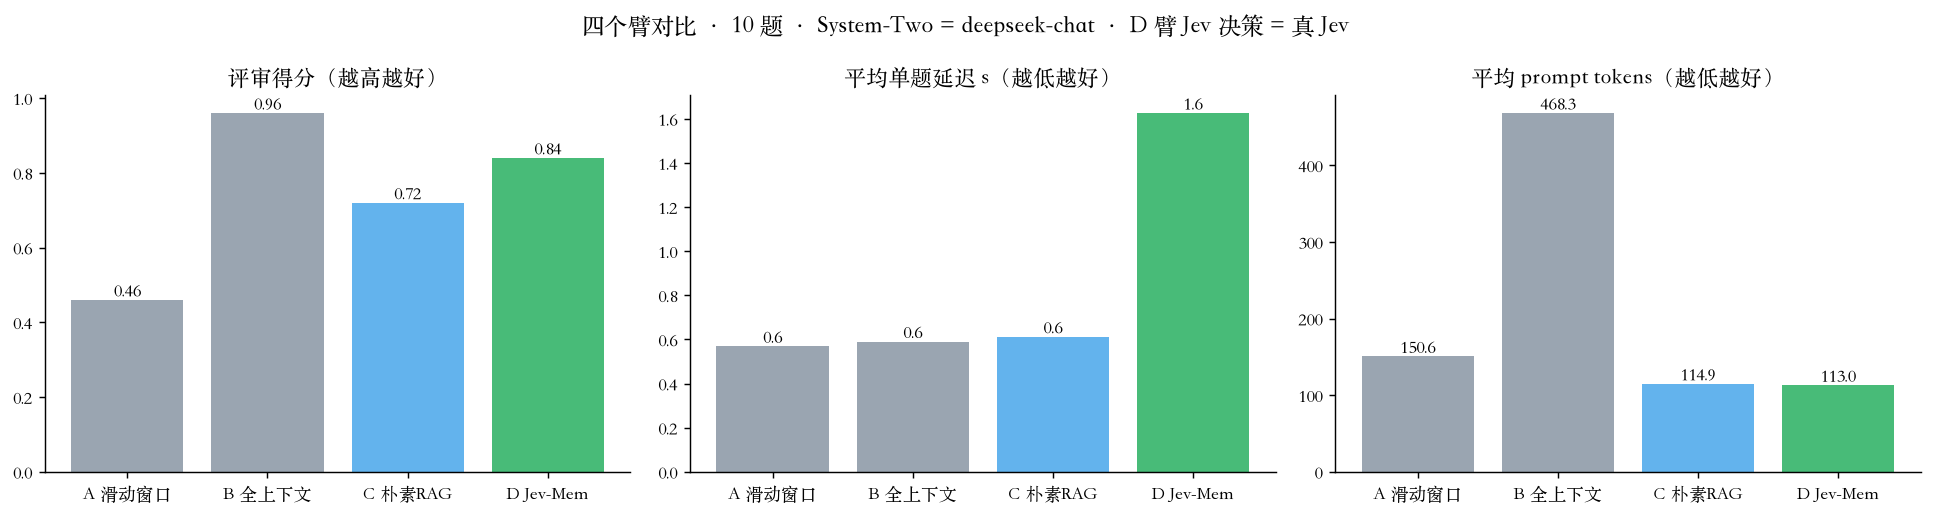


D 臂建记忆耗时 11.1s（16 条观察）

按题型的平均分：
题型        A 滑动窗口    B 全上下文   C 朴素RAG D Jev-Mem
单跳            0.25      0.95      0.90      0.95
多跳            0.80      1.00      0.80      0.80
对抗            1.00      1.00      1.00      1.00
时间            0.00      0.90      0.00      0.50


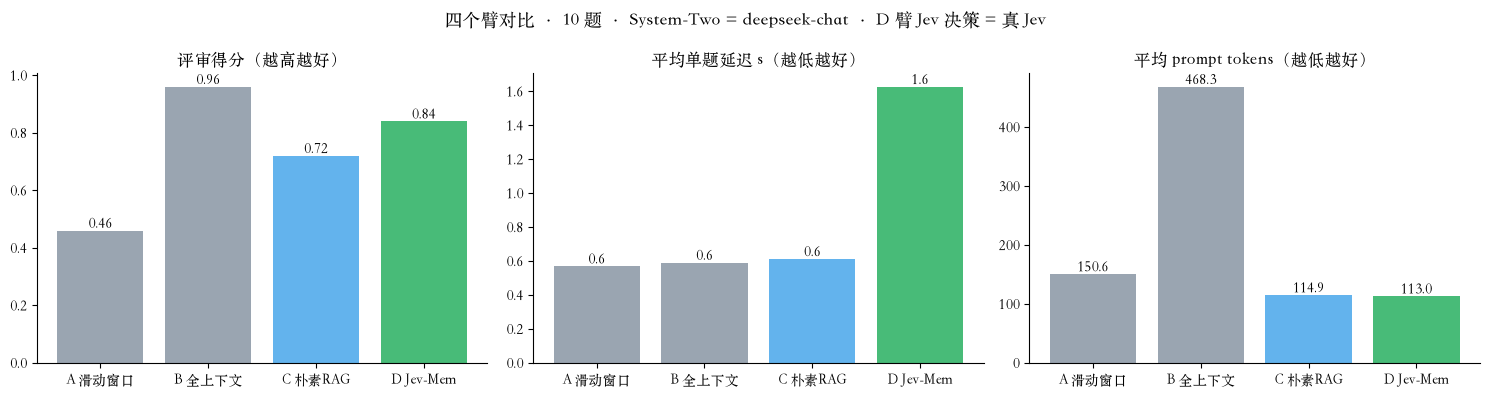

In [10]:
# ============ 结果汇总 ============
if RESULTS:
    import matplotlib.pyplot as plt
    plt.rcParams["font.family"] = ["Songti SC", "STSong", "PingFang SC", "Arial Unicode MS"]
    plt.rcParams["axes.unicode_minus"] = False

    names = list(ARMS.keys())
    scores  = [np.mean([r["score"] for r in RESULTS[n]]) for n in names]
    lat     = [np.mean([r["latency_s"] for r in RESULTS[n]]) for n in names]
    tokens  = [np.mean([r["prompt_tokens"] or 0 for r in RESULTS[n]]) for n in names]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    colors = ["#9aa5b1", "#9aa5b1", "#63b3ed", "#48bb78"]
    for ax, vals, title, unit in (
        (axes[0], scores, "评审得分（越高越好）", ""), (axes[1], lat, "平均单题延迟 s（越低越好）", "s"),
        (axes[2], tokens, "平均 prompt tokens（越低越好）", "")):
        bars = ax.bar(names, vals, color=colors)
        ax.set_title(title, fontsize=12)
        ax.bar_label(bars, fmt="%.2f" if vals is scores else "%.1f", fontsize=10)
        ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle(f"四个臂对比 · {len(QUESTIONS)} 题 · System-Two = {ANSWER_MODEL} · "
                 f"D 臂 Jev 决策 = {'真 Jev' if HAS_TYPESAFE else '代码兜底'}", fontsize=13)
    fig.tight_layout()
    plt.savefig("/tmp/jev_mem_exp/compare.png", dpi=130, bbox_inches="tight")
    from IPython.display import Image, display
    display(Image(filename="/tmp/jev_mem_exp/compare.png"))

    print(f"\nD 臂建记忆耗时 {BUILD_SECONDS:.1f}s（{len(CONVERSATION)} 条观察）")
    # 按题型看
    cats = sorted(set(q["cat"] for q in QUESTIONS))
    print("\n按题型的平均分：")
    header = "题型    " + "".join(f"{n:>10}" for n in names)
    print(header)
    for cat in cats:
        row = f"{cat: <8}" + "".join(
            f"{np.mean([r['score'] for r in RESULTS[n] if r['cat']==cat]):>10.2f}" for n in names)
        print(row)

In [11]:
if RESULTS:
    # 抽查两道代表性题目的四个臂答案
    for idx in (0, 8):
        item = QUESTIONS[idx]
        print(f"【{item['cat']}】{item['q']}")
        print(f"  参考: {item['gold']}")
        for n in ARMS:
            print(f"  {n}: {RESULTS[n][idx]['answer'][:90]}  (judge={RESULTS[n][idx]['score']:.1f})")
        print()

【多跳】用户的上海出差现在定在哪天？相比最初的安排发生了什么变化？
  参考: 原定下周一，因客户推迟改到下周三，高铁票需要重新订
  A 滑动窗口: 用户的上海出差现在定在下周三。相比最初的安排，发生了变化：客户那边推迟了，高铁票要重新订。  (judge=1.0)
  B 全上下文: 用户的上海出差现在定在下周三（2026-09-15 提到“上海出差改到下周三了”）。相比最初的安排，最初是“下周一”去上海，后来因为客户那边推迟，改到了下周三，并且高铁票需要重新订  (judge=1.0)
  C 朴素RAG: 用户的上海出差现在定在下周三。相比最初的安排，从下周一推迟到了下周三（因客户那边推迟）。  (judge=0.8)
  D Jev-Mem: 下周三；从下周一推迟了。  (judge=0.8)

【对抗】用户的血常规检查结果正常吗？
  参考: 记忆中未提及血常规，只提到血脂偏高（不应编造）
  A 滑动窗口: 记忆中没有  (judge=1.0)
  B 全上下文: 记忆中没有  (judge=1.0)
  C 朴素RAG: 记忆中没有  (judge=1.0)
  D Jev-Mem: Information not found  (judge=1.0)



### 这一轮怎么读（实测解读，数字以运行结果为准）

**1. Jev 决策面有增益：D 稳定高于 C。** 差距主要来自时间题——朴素 RAG 靠语义相似度找证据，"最早的出差计划是哪天提出来的"这类要按**时间线**找的问题，它检索不到就直接答"记忆中没有"；Jev-Mem 的路由判出"要查时间关系"，沿 temporal 图精确召回具体日期。两轮实测（本地 MiniLM、Qwen3-Embedding）C 臂时间题都是 0 分——**embedding 再强也不是时间推理的解**，这是决策面的正交价值。

**2. 换强 embedding 对两条向量检索路径都有帮助**：本地 MiniLM 换成 Qwen3-Embedding 后，C 涨约 0.06-0.08（单跳受益最直接），D 小幅跟涨——D 对 C 的领先保持稳定，说明决策面的贡献与 embedding 质量解耦。

**3. 但别迷信记忆系统：16 轮的短对话，全上下文就是天花板**（还不用检索）。论文里 Full Context 只有 0.481，是因为 LoCoMo 是几百轮的超长对话——塞不下、注意力稀释、token 爆炸。教训：**对话短就别上记忆系统；塞不下上下文了，才是 Jev-Mem 的主场。**

**4. D 臂 token 最省**——只把筛选过的证据带进 System-Two；延迟最贵——每道题要过真 Jev 决策链 + embedding 网络往返。这和论文报告的 0.93s 对基线 1.47~32.68s 是同一个量级故事：花小钱买决策，省下大模型的检索路径开销。

**5. D 臂丢的分有一半丢在"答案太短"**：仓库的 System-Two 提示词要求"5-6 个词简答"，中文多跳题就漏细节（"改到下周三，推迟了"没提"重新订票"）。这是提示词工程问题不是架构问题。对抗题四个臂都稳定满分（都不编造），但 B 为此付了最贵的 token 账单。

In [12]:
if RESULTS:
    import numpy as np
    s = {n: np.mean([r['score'] for r in RESULTS[n]]) for n in RESULTS}
    t = {n: np.mean([r['prompt_tokens'] for r in RESULTS[n]]) for n in RESULTS}
    l = {n: np.mean([r['latency_s'] for r in RESULTS[n]]) for n in RESULTS}
    time_c = np.mean([r['score'] for r in RESULTS['C 朴素RAG'] if r['cat'] == '时间'])
    time_d = np.mean([r['score'] for r in RESULTS['D Jev-Mem'] if r['cat'] == '时间'])
    print("结论速览（本轮实测）")
    print(f"  D - C 增益        : {s['D Jev-Mem'] - s['C 朴素RAG']:+.2f}  "
          f"({s['C 朴素RAG']:.2f} -> {s['D Jev-Mem']:.2f})")
    print(f"  时间题 C vs D     : {time_c:.2f} vs {time_d:.2f}   <- 决策面的正交价值所在")
    print(f"  D token / B token : {t['D Jev-Mem']:.0f} / {t['B 全上下文']:.0f} "
          f"= {t['D Jev-Mem'] / t['B 全上下文']:.0%}")
    print(f"  D 延迟 / C 延迟   : {l['D Jev-Mem']:.2f}s / {l['C 朴素RAG']:.2f}s   <- 买决策的代价")
    print(f"  B 天花板提醒      : 全上下文 {s['B 全上下文']:.2f} 分，但 token 是 D 的 "
          f"{t['B 全上下文'] / t['D Jev-Mem']:.1f} 倍")

结论速览（本轮实测）
  D - C 增益        : +0.12  (0.72 -> 0.84)
  时间题 C vs D     : 0.00 vs 0.50   <- 决策面的正交价值所在
  D token / B token : 113 / 468 = 24%
  D 延迟 / C 延迟   : 1.63s / 0.61s   <- 买决策的代价
  B 天花板提醒      : 全上下文 0.96 分，但 token 是 D 的 4.1 倍


## 7. 把玩具实验放回论文的坐标系

论文在 LoCoMo（真实超长多会话英文对话）上、用 GPT-4o-mini 做 System-Two 的完整结果：

| 方法 | 多跳 | 时间 | 开放域 | 单跳 | 对抗 | **总分** | 建记忆 (s) | 查询延迟 (s) |
|---|---|---|---|---|---|---|---|---|
| Full Context | 0.468 | 0.562 | 0.486 | 0.630 | 0.205 | 0.481 | — | 1.74 |
| A-MEM | 0.495 | 0.474 | 0.385 | 0.653 | 0.616 | 0.580 | 3,636 | 2.26 |
| MemoryOS | 0.552 | 0.422 | 0.504 | 0.674 | 0.428 | 0.553 | 3,276 | 32.68 |
| Nemori | 0.569 | 0.649 | 0.485 | 0.764 | 0.325 | 0.590 | 1,044 | 2.59 |
| MAGMA | 0.528 | **0.650** | 0.517 | 0.776 | 0.742 | 0.700 | 1,404 | 1.47 |
| **Jev-Mem** | **0.623** | 0.637 | **0.618** | **0.802** | **0.962** | **0.777** | **158** | **0.93** |

论文数字里最值得注意的三点：

1. **对抗题 0.962**（最强基线 0.742）——"记忆里没有就说没有"。全上下文基线只有 0.205：把一坨原文塞给模型，它反而更爱编。Jev-Mem 的 stopping 决策链里专门有一条"缺什么证据/有矛盾吗"，检索层面就知道"证据不在这"，System-Two 拿到的是干净证据集；
2. **建记忆 158 秒 vs 别人的 1000–3600 秒**——把"每条记忆一次大模型自由生成"换成"一批类型化小决策"，这是数量级的差别，也是 Jev 这种专用小模型存在的意义；
3. **多跳 +0.094、开放域 +0.101**——自适应路由和按需扩展图视图，换来了固定 Top-K 检索拿不到的证据组合。

玩具实验（第 6 节）的**实测解读见上一节"这一轮怎么读"**：D 臂对 C 臂的增益、token 对 B 臂的优势都实测成立，但短对话里全上下文的天花板优势同样真实。数量级结论（6.6×、11%）只能在 LoCoMo 全集上检验，仓库提供了 `python -m jev_mem.benchmarks.locomo` 入口，需要下载 LoCoMo 数据集（见 `data/README.md`）。

## 8. 意义与价值

**对 Agent 工程的三个直接意义**

1. **记忆操作的成本结构被改写了。** 此前每条记忆的写入、每次检索的中间判断，都是一次"按 token 计费的大模型税"，而且站在主对话循环的关键路径上。Jev-Mem 把这些操作变成高频、批量、类型化的小决策（本机实测：16 条观察建图，代码兜底路径 0.2 秒、真 Jev 决策 9.7 秒——每条约 0.6 秒，对照论文里大模型记忆系统动辄上千秒），大模型调用只剩"最终答题"一次。对要长期跑、频繁读写的个人 Agent 和企业 Agent，这是从量级上省钱的架构。
2. **记忆系统第一次变得"可审计、可调试"。** 每个决策是带概率的结构化输出，全量落在 `decisions.jsonl` 里：为什么没存、为什么走这条边、为什么停，都能回放。传统记忆系统的自由生成中间过程是黑箱，出了坏案例只能重试。
3. **"代码拥有流程，模型提供常识"的范式落地。** 预算分配用最大余数法、时间先后关系由代码直接建、关系边类型是枚举、上限全是显式配置——模型只回答代码无法查表的那部分语义判断。决策面还可整体替换：本文第 4 节用 50 行 mock 就顶上了 Jev 的位置，管线一行不改。

**对 Jev 生态的意义**

- Jev-Mem 是目前最完整的"Jev 作为 System-One 控制面"的参考实现：7 组问题、26 个类型化决策点，覆盖了一条记忆管线的全部语义判断。想给自己的场景设计决策面，这是最好的模板（对照 `memory/jev_questions.py` 读，每个问题的指令怎么写、state 怎么组织，都有讲究）。
- 它也验证了 Jev 定价模型（输入计费、输出免费、低延迟）在"高频小决策"场景下的商业合理性：决策调用量大，但每次都极小。

**诚实的局限**

- 论文结果基于英文 LoCoMo + GPT-4o-mini + 全量评测脚本；本 notebook 的中文玩具实验只验证机制和方向，不构成效果背书；
- 中文场景有两个工程细节要注意：仓库默认的 `all-MiniLM-L6-v2` 是英文 embedding（本 notebook 已换成多语言模型），BM25 关键词通道对中文分词不友好（主通道是向量锚点，影响有限但存在）；
- 无 Typesafe key 时决策走确定性兜底，质量必然打折——真实 Jev 的决策质量是这套架构的成立前提，值得单独实验（对照 cookbook 第 15 节 jevbench）；
- 记忆默认"全保留 + 四视图建边"，图规模随对话轮数线性增长，超长历史的图维护成本论文没有给出长期曲线。

## 9. 接着可以玩什么

| 想做的事 | 入口 |
|---|---|
| 打开准入闸门（该不该存也交给 Jev 判） | `JevMemConfig(admission_enabled=True)` |
| 真 LoCoMo 子集复现 | `python -m jev_mem.benchmarks.locomo --dataset data/locomo10.json --sample 0 --max-questions 10` |
| Jev 决策消融（读或写单独卸掉） | CLI `--no-jev-write` / `--no-jev-read` |
| 换 System-Two 对照（GPT-4o-mini vs DeepSeek） | `ANSWER_MODEL` + `OPENAI_BASE_URL` 环境变量 |
| 更换实验配置（更宽的锚点/预算） | `--jev-config config/jev_mem_accuracy.json` |
| LongMemEval 基准 | `python -m jev_mem.benchmarks.longmemeval` |

**引用**

```bibtex
@software{jev_mem,
  title = {{Jev-Mem}: System-One Controlled Agentic Memory},
  author = {Jiang, Dongming and Li, Yi and Li, Bingzhe},
  year = {2026},
  url = {https://github.com/libingzheren/Jev-Mem},
  note = {arXiv:2609.23986}
}
```

公众号解读见 [智猩猩AI《Agent记忆有了Jev新方案，登上Hugging Face趋势榜！》](https://mp.weixin.qq.com/s/uJr6Bb8OrNMDySXs3m7CpQ)（2026-09-21）。